# Customer Segmentation using K-Means
## (Unsupervised Machine Learning Project)

# Step 1: Project ka Overview (Introduction)
Is project ka maqsad yeh samajhna hai ke Machine Learning ka use karke customers ko groups me kaise divide kiya jata hai.

- Is project me hum Unsupervised Learning use kar rahe hain, jisme:

- Sirf input data hota hai

- Koi label / answer pehle se nahi hota

- Model khud patterns aur clusters banata hai

Hum K-Means Clustering algorithm use karenge jo customers ko unke income aur spending behaviour ke basis par groups me divide karta hai.

# Step 2: Libraries Import Karna
Sab se pehle hum wo libraries import karte hain jo:

- Data load karne

- Data analyse karne

- Graphs banane

- Machine learning model train karne

ke liye zaroori hoti hain.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


# Step 3: Dataset ko Load Karna
Ab hum apna dataset Python me load karenge taake hum usko dekh aur samajh saken.
Pandas ek library hai jo CSV files ko easily read karti hai.

In [9]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# # Step 4: Dataset ko Samajhna (Basic EDA)
4.1 Dataset ka Size Check Karna

Is step me hum dekhte hain ke dataset me:

Kitni rows (customers) hain

Kitne columns (features) hain

In [10]:
df.shape

(200, 5)

In [11]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [13]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Step 5: Feature Selection

Ab hum sirf wo columns select karte hain jo clustering ke liye useful hain.

Hum CustomerID is liye remove karte hain kyun ke wo sirf identification hai.
Gender is liye use nahi karte kyun ke wo categorical hai.

In [14]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 6: Data Visualization (EDA ka Important Part)

Ab hum scatter plot banate hain taake:

- Income

- Spending

ka relationship visually samajh aaye.

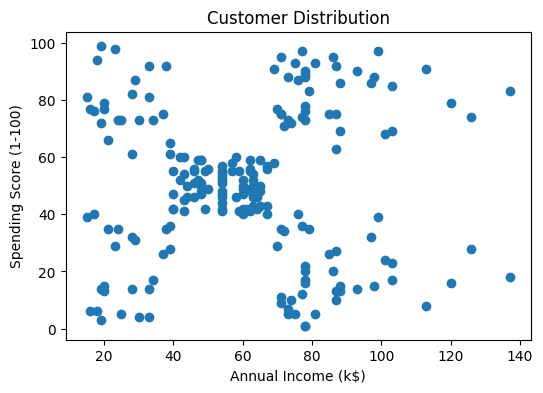

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")
plt.show()

# Step 7: Machine Learning Start

## (K-Means – Unsupervised Learning)

K-Means algorithm data ko K number ke clusters me divide karta hai.
Lekin pehle humein yeh decide karna hota hai ke K ki value kya honi chahiye.

# Step 8: Elbow Method (Best K Choose Karna)

Elbow Method ka use karke hum different K values try karte hain.

In [16]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


- Ab hum graph banate hain:

- Graph se humein pata chalta hai ke K = 5 best hai.

# Step 9: K-Means Model Apply Karna

Ab hum final model train karte hain K = 5 ke sath.

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Step 10: Final Cluster Visualization

Ab hum dekhte hain ke customers kaise clusters me divide huay hain.

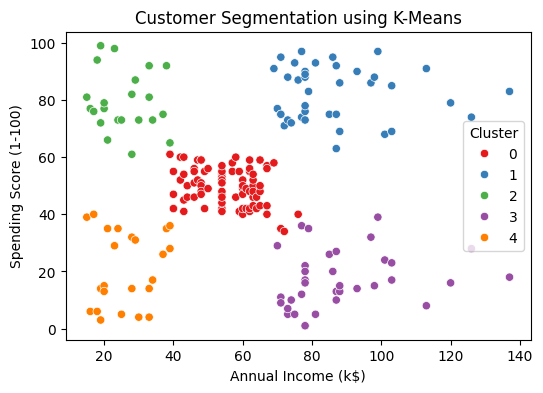

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1'
)
plt.title("Customer Segmentation using K-Means")
plt.show()

# Step 11: Results ka Matlab

- Cluster 0: Kam income – kam spending

- Cluster 1: Zyada income – zyada spending

- Cluster 2: Zyada income – kam spending

- Cluster 3: Kam income – zyada spending

- Cluster 4: Average customers

## Business in clusters ko use kar ke:

- Target marketing

- Special offers

- Customer retention

- plan kar sakta hai.